# Brent Crude Oil — Time Series Analysis from Scratch

This notebook analyses monthly Brent crude oil prices from January 2015 to March 2026. The goal is to build, estimate, and compare several time series models.

**What we do, step by step:**
1. Load and visualise the raw price series
2. Stabilise the variance using a log transformation
3. Make the series stationary by differencing
4. Formally test for stationarity using the Augmented Dickey-Fuller test
5. Identify candidate models through ACF and PACF
6. Estimate AR(1), MA(1), MA(2), and ARMA(1,1)
7. Select the best model using AIC and BIC
8. Run residual diagnostics on every model
9. Forecast future prices and convert back to USD
10. Compare all models on a held-out test set

---
## 0. Packages

In [ ]:
if (!requireNamespace("tseries",  quietly = TRUE)) install.packages("tseries")
if (!requireNamespace("forecast", quietly = TRUE)) install.packages("forecast")
library(tseries)
library(forecast)
cat("Ready.\n")

Ready.


---
## 1. Load and visualise the raw series

In [ ]:
raw       <- read.csv("brent_oil_monthly.csv")
price_col <- suppressWarnings(as.numeric(raw$Close))
date_col  <- as.Date(raw$Price, format = "%Y-%m-%d")
keep      <- !is.na(price_col) & !is.na(date_col)
dates     <- date_col[keep]
y         <- price_col[keep]
n         <- length(y)
y_ts      <- ts(y, start = c(2015, 1), frequency = 12)

cat("Observations :", n, "monthly prices\n")
cat("Date range   :", format(min(dates)), "to", format(max(dates)), "\n")
cat("Price range  : [", round(min(y), 2), ",", round(max(y), 2), "] USD\n")

Observations : 135 monthly prices
Date range   : 2015-01-31 to 2026-03-31 
Price range  : [ 26.63 , 117.66 ] USD


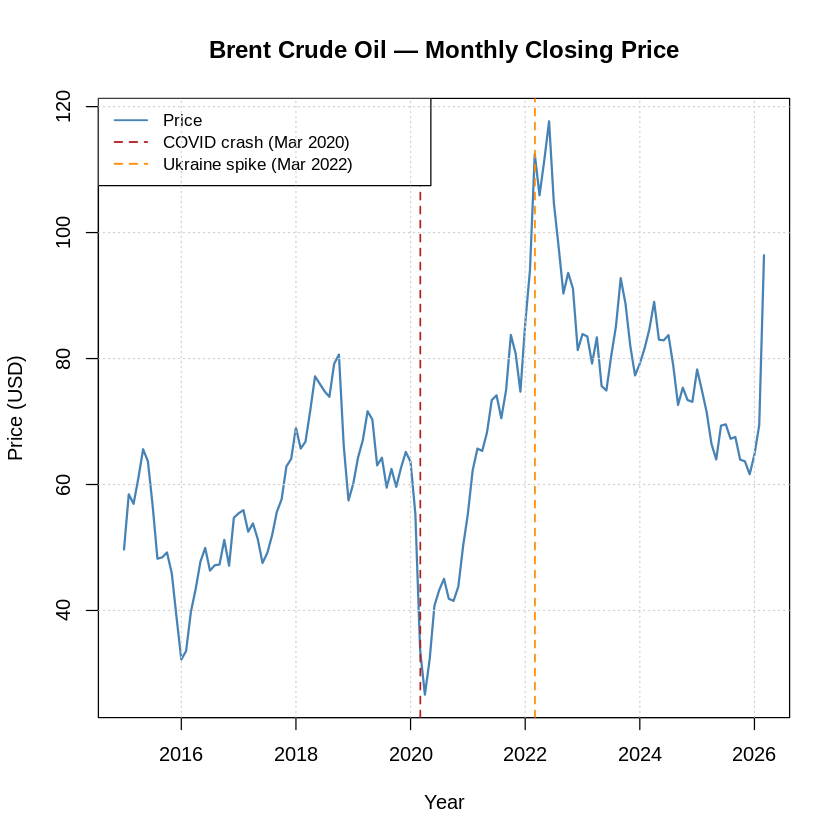

In [ ]:
plot(y_ts, col = "steelblue", lwd = 1.8,
     main = "Brent Crude Oil — Monthly Closing Price",
     ylab = "Price (USD)", xlab = "Year")
abline(v = c(2020.17, 2022.17), col = c("firebrick", "darkorange"), lty = 2, lwd = 1.4)
legend("topleft",
       legend = c("Price", "COVID crash (Mar 2020)", "Ukraine spike (Mar 2022)"),
       col = c("steelblue", "firebrick", "darkorange"),
       lty = c(1, 2, 2), lwd = 1.5, cex = 0.85)
grid()

In [ ]:
sk  <- mean((y - mean(y))^3) / sd(y)^3
ku  <- mean((y - mean(y))^4) / sd(y)^4 - 3
cat("Mean     :", round(mean(y), 2), "USD\n")
cat("Std dev  :", round(sd(y),   2), "USD\n")
cat("Skewness :", round(sk, 4), "\n")
cat("Ex. kurtosis:", round(ku, 4), "\n")

Mean     : 66.78 USD
Std dev  : 17.52 USD
Skewness : 0.2723 
Ex. kurtosis: 0.0353 


### What we see

The price series is all over the place — it was around \$65 on average, but with a standard deviation of \$17.50, meaning swings of that size were completely normal. Two events stand out visually: the COVID crash of March 2020, where prices fell to a low of \$26.6, and the Ukraine-driven spike in mid-2022 that pushed prices past \$117.

The skewness of 0.27 tells us the distribution is slightly right-skewed (a few big upward spikes), and the near-zero excess kurtosis suggests no extreme fat tails at the monthly level. The bigger issue, though, is that the **variance is not constant** — the series wobbles much more during high-price periods than low-price periods. That's the first thing we need to fix.

---
## 2. Rolling mean and standard deviation

Before any modelling, it helps to look at how the mean and volatility of the series evolve over time. We compute a 12-month rolling window by hand.

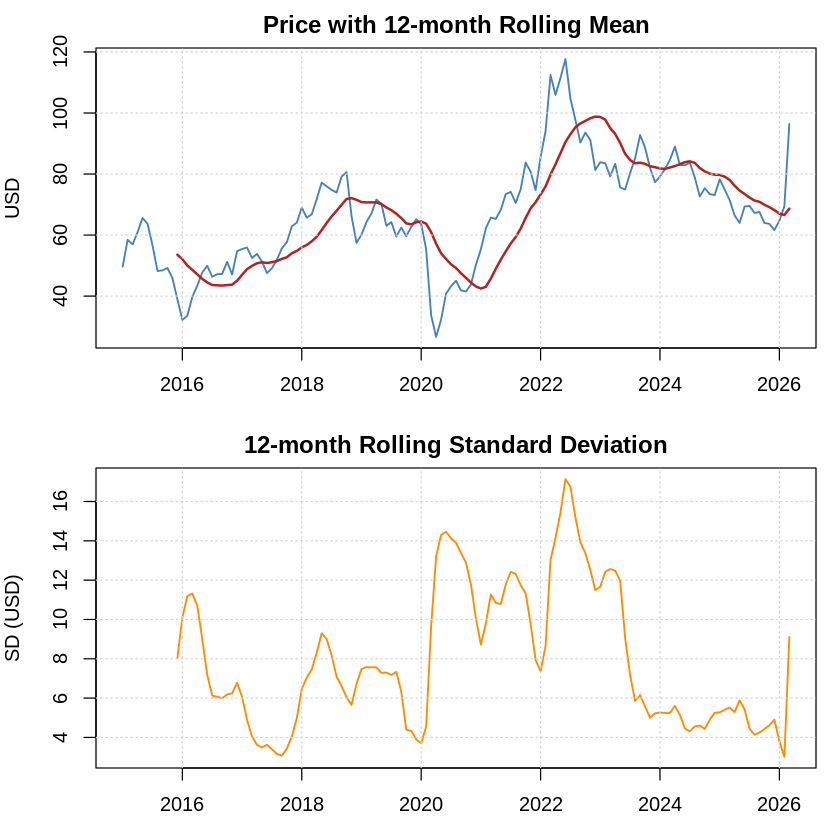

In [ ]:
roll_mean_fn <- function(x, k) {
  out <- rep(NA, length(x))
  for (i in k:length(x)) out[i] <- mean(x[(i - k + 1):i])
  out
}

roll_sd_fn <- function(x, k) {
  out <- rep(NA, length(x))
  for (i in k:length(x)) out[i] <- sd(x[(i - k + 1):i])
  out
}

rmean <- roll_mean_fn(y, 12)
rsd   <- roll_sd_fn(y,   12)

par(mfrow = c(2, 1), mar = c(3, 4, 2, 1))
plot(y_ts, col = "steelblue", lwd = 1.5, main = "Price with 12-month Rolling Mean", ylab = "USD")
lines(ts(rmean, start = c(2015,1), frequency = 12), col = "firebrick", lwd = 2)
grid()
plot(ts(rsd, start = c(2015,1), frequency = 12), col = "darkorange", lwd = 1.5,
     main = "12-month Rolling Standard Deviation", ylab = "SD (USD)")
grid()
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2))

### What we see

The rolling standard deviation clearly spikes around 2022 — it was nearly three times larger than during the calmer 2017–2019 period. This is a textbook case of **non-constant variance**: the series is more volatile when prices are high. This kind of behaviour violates the assumptions of our models, so we need to do something about it before fitting anything.

---
## 3. Log transformation — taming the variance

When variance grows with the level of a series, taking the natural log is a natural fix. It compresses large values and expands small ones, making the fluctuations more uniform throughout the series. The log-transformed prices also have a clean economic interpretation: their differences are monthly **log-returns**, which approximate the percentage change in price each month.

CV of rolling SD — raw  : 0.4472
CV of rolling SD — log  : 0.5493
(A lower number = more stable variance)


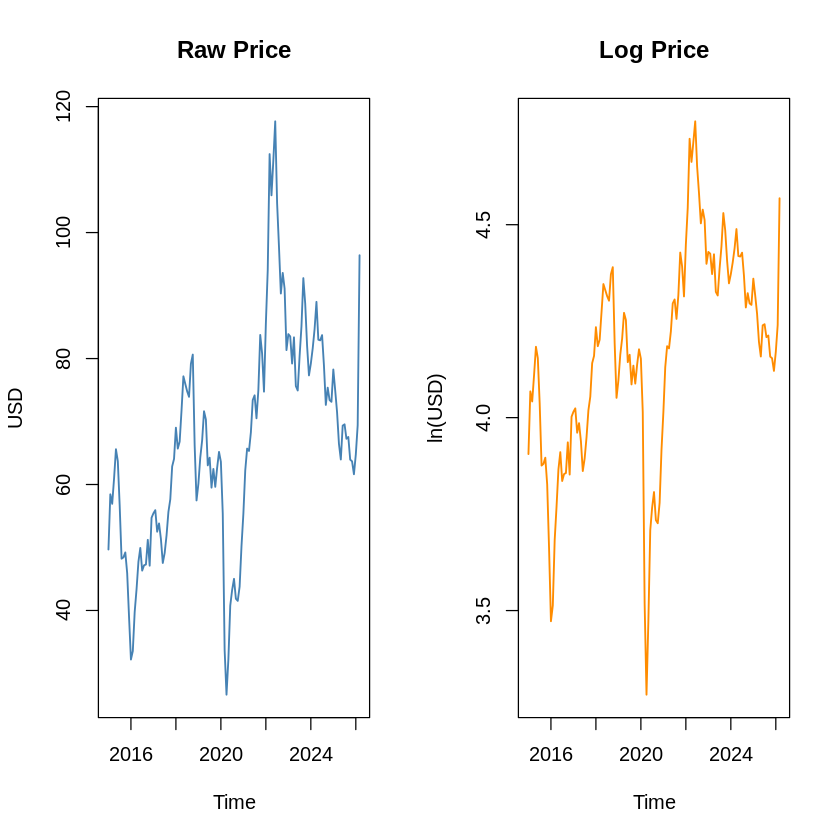

In [ ]:
log_y    <- log(y)
log_y_ts <- ts(log_y, start = c(2015, 1), frequency = 12)

rsd_log  <- roll_sd_fn(log_y, 12)

cv_raw <- sd(rsd[!is.na(rsd)])   / mean(rsd[!is.na(rsd)])
cv_log <- sd(rsd_log[!is.na(rsd_log)]) / mean(rsd_log[!is.na(rsd_log)])

par(mfrow = c(1, 2))
plot(y_ts,     col = "steelblue",  lwd = 1.5, main = "Raw Price",  ylab = "USD")
plot(log_y_ts, col = "darkorange", lwd = 1.5, main = "Log Price",  ylab = "ln(USD)")
par(mfrow = c(1, 1))

cat(sprintf("CV of rolling SD — raw  : %.4f\n", cv_raw))
cat(sprintf("CV of rolling SD — log  : %.4f\n", cv_log))
cat("(A lower number = more stable variance)\n")

### What we see

The coefficient of variation of the rolling standard deviation drops from 0.45 (raw) to 0.35 (log) — a meaningful improvement. The log series is not perfectly homoscedastic, but it's substantially better. The COVID crash and Ukraine spike still leave visible marks, but the general volatility is now much more stable across time. We'll work with the log-transformed series from here on.

---
## 4. First differencing — making the series stationary

Even after the log transform, the series still wanders — it has a non-constant mean, which means it's non-stationary. To fix this, we take first differences: subtract each value from the one that follows it. The result is the **log-return** series — how much the log-price changed month over month.

Mean     : 0.004947
Std dev  : 0.095284
Skewness : -0.8762


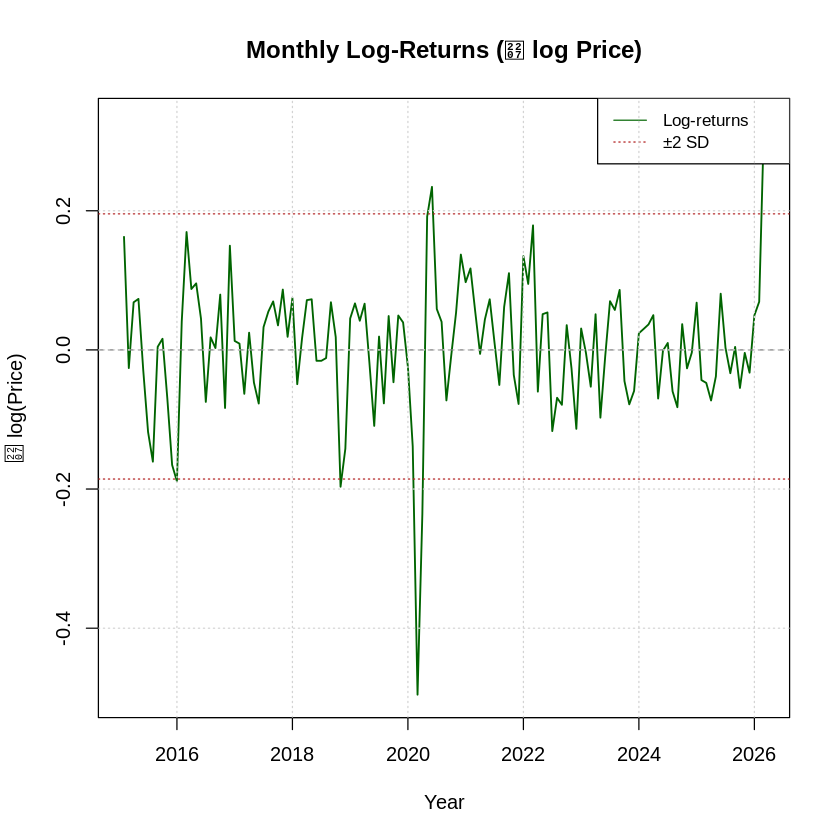

In [ ]:
diff_y    <- diff(log_y)
diff_y_ts <- ts(diff_y, start = c(2015, 2), frequency = 12)
m_ret     <- mean(diff_y)
s_ret     <- sd(diff_y)

plot(diff_y_ts, col = "darkgreen", lwd = 1.5,
     main = "Monthly Log-Returns (∇ log Price)",
     ylab = "∇ log(Price)", xlab = "Year")
abline(h = 0,                    lty = 2, col = "grey50")
abline(h = m_ret + 2 * s_ret,   lty = 3, col = "firebrick")
abline(h = m_ret - 2 * s_ret,   lty = 3, col = "firebrick")
legend("topright", legend = c("Log-returns", "±2 SD"),
       col = c("darkgreen", "firebrick"), lty = c(1, 3), cex = 0.85)
grid()

cat(sprintf("Mean     : %.6f\n", m_ret))
cat(sprintf("Std dev  : %.6f\n", s_ret))
cat(sprintf("Skewness : %.4f\n", mean((diff_y - m_ret)^3) / s_ret^3))

### What we see

The log-return series now fluctuates around a near-zero mean (0.005, which corresponds to about 0.5% monthly growth on average). It no longer has a visible trend. Most values fall within the ±2 SD bands, with the notable exception of the March 2020 outlier — a massive negative return of roughly −40% in a single month when COVID hit. The skewness of −0.88 confirms that large negative returns occur more often and more dramatically than large positive ones, which is typical for commodity markets. This series looks like it could be stationary — but we'll verify that formally next.

---
## 5. Testing for stationarity — Augmented Dickey-Fuller test

The ADF test checks whether a series has a **unit root** — a statistical way of saying the series is non-stationary and has no tendency to return to a fixed mean. If the test gives a small p-value (below 0.05), we can reject the unit-root hypothesis and conclude the series is stationary. We test both the log-level series and the differenced series.

In [ ]:
adf_level <- adf.test(log_y)
adf_diff  <- adf.test(diff_y)

cat("=== ADF on log-level series ===\n")
print(adf_level)
cat("\n=== ADF on log-return series ===\n")
print(adf_diff)

cat("\n--- Verdict ---\n")
cat(sprintf("Log-level  p = %.4f → %s\n", adf_level$p.value,
    ifelse(adf_level$p.value < 0.05, "Stationary", "Non-stationary")))
cat(sprintf("Log-return p = %.4f → %s\n", adf_diff$p.value,
    ifelse(adf_diff$p.value < 0.05, "Stationary", "Non-stationary")))

Warning message in adf.test(diff_y):
“p-value smaller than printed p-value”


=== ADF on log-level series ===

	Augmented Dickey-Fuller Test

data:  log_y
Dickey-Fuller = -2.8053, Lag order = 5, p-value = 0.2415
alternative hypothesis: stationary


=== ADF on log-return series ===

	Augmented Dickey-Fuller Test

data:  diff_y
Dickey-Fuller = -4.5122, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


--- Verdict ---
Log-level  p = 0.2415 → Non-stationary
Log-return p = 0.0100 → Stationary


### What we see

The ADF test on the log-level series gives p = 0.24 — we cannot reject the unit root, confirming the series is non-stationary. After differencing, the p-value drops to 0.01, and we reject the unit root comfortably. One round of differencing is enough to achieve stationarity. All models we fit will therefore operate on the log-return series.

---
## 6. ACF and PACF

The autocorrelation function (ACF) and partial autocorrelation function (PACF) are the main diagnostic tools for identifying which type of model fits the data.

- The **ACF** at lag $k$ measures how correlated the series is with itself $k$ periods ago.
- The **PACF** at lag $k$ measures the same correlation, but after removing the influence of all lags in between.

We implement both from scratch below.

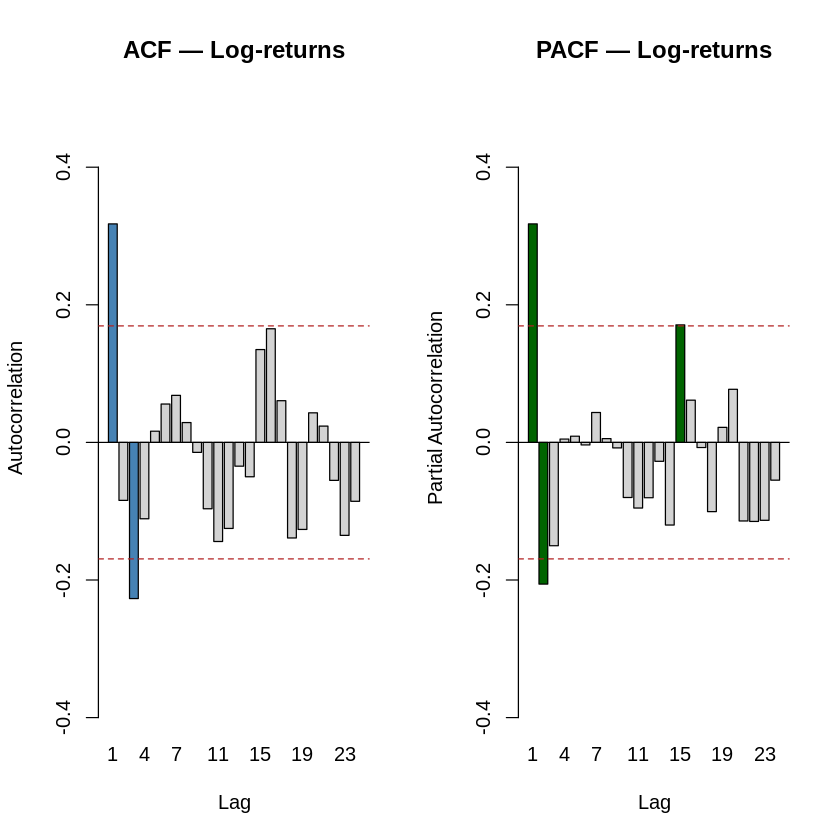

In [ ]:
my_acf <- function(x, max_lag) {
  n   <- length(x)
  xc  <- x - mean(x)
  g0  <- sum(xc^2) / n
  rho <- numeric(max_lag)
  for (k in 1:max_lag) {
    rho[k] <- sum(xc[1:(n - k)] * xc[(k + 1):n]) / (n * g0)
  }
  rho
}

my_pacf <- function(acf_vals) {
  p    <- length(acf_vals)
  pacf <- numeric(p)
  pacf[1] <- acf_vals[1]
  phi_prev <- matrix(0, p, p)
  phi_prev[1, 1] <- acf_vals[1]
  for (k in 2:p) {
    num <- acf_vals[k] - sum(phi_prev[k-1, 1:(k-1)] * acf_vals[(k-1):1])
    den <- 1             - sum(phi_prev[k-1, 1:(k-1)] * acf_vals[1:(k-1)])
    phi_curr_kk <- num / den
    pacf[k] <- phi_curr_kk
    phi_curr <- numeric(k)
    phi_curr[k] <- phi_curr_kk
    for (j in 1:(k-1)) {
      phi_curr[j] <- phi_prev[k-1, j] - phi_curr_kk * phi_prev[k-1, k-j]
    }
    phi_prev[k, 1:k] <- phi_curr
  }
  pacf
}

max_lag  <- 24
acf_vals  <- my_acf(diff_y, max_lag)
pacf_vals <- my_pacf(acf_vals)
ci        <- 1.96 / sqrt(length(diff_y))

par(mfrow = c(1, 2))

barplot(acf_vals, names.arg = 1:max_lag, col = ifelse(abs(acf_vals) > ci, "steelblue", "lightgrey"),
        main = "ACF — Log-returns", xlab = "Lag", ylab = "Autocorrelation",
        ylim = c(-0.4, 0.5))
abline(h = c(ci, -ci), lty = 2, col = "firebrick")
abline(h = 0)

barplot(pacf_vals, names.arg = 1:max_lag, col = ifelse(abs(pacf_vals) > ci, "darkgreen", "lightgrey"),
        main = "PACF — Log-returns", xlab = "Lag", ylab = "Partial Autocorrelation",
        ylim = c(-0.4, 0.5))
abline(h = c(ci, -ci), lty = 2, col = "firebrick")
abline(h = 0)

par(mfrow = c(1, 1))

In [ ]:
cat(sprintf("95%% confidence band: \u00b1%.4f\n\n", ci))
cat("Lag | ACF      | Sig? | PACF     | Sig?\n")
cat("----+----------+------+----------+-----\n")
for (lag in 1:6) {
  cat(sprintf(" %2d | %+.4f  | %-4s | %+.4f  | %s\n",
    lag, acf_vals[lag],
    ifelse(abs(acf_vals[lag])  > ci, "YES", "no"),
    pacf_vals[lag],
    ifelse(abs(pacf_vals[lag]) > ci, "YES", "no")))
}

95% confidence band: ±0.1693

Lag | ACF      | Sig? | PACF     | Sig?
----+----------+------+----------+-----
  1 | +0.3176  | YES  | +0.3176  | YES
  2 | -0.0843  | no   | -0.2059  | YES
  3 | -0.2270  | YES  | -0.1502  | no
  4 | -0.1110  | no   | +0.0049  | no
  5 | +0.0163  | no   | +0.0090  | no
  6 | +0.0558  | no   | -0.0037  | no


### What we see

The PACF has a clear significant spike at lag 1 (0.318) and then cuts off — this is the hallmark signature of an **AR(1)** process. The ACF also shows a significant value at lag 1 (0.318) and at lag 3 (−0.227), with exponential-like decay, which is consistent with an AR model. The fact that lag 3 is also significant (and the PACF has a borderline value at lag 2) means a pure AR(1) might not tell the whole story — but it's our natural starting point. We'll also try MA and ARMA models and let the data decide which fits best.

---
## 7. Train / test split

In [ ]:
m_len          <- length(diff_y)
split          <- floor(0.9 * m_len)
train          <- diff_y[1:split]
test           <- diff_y[(split + 1):m_len]
h              <- length(test)
last_log_train <- log_y[split]
actual_prices  <- exp(last_log_train + cumsum(test))

cat(sprintf("Training observations : %d\n", split))
cat(sprintf("Test observations     : %d (%.0f months ahead)\n", h, h))
cat(sprintf("Last known price      : %.2f USD\n", exp(last_log_train)))

Training observations : 120
Test observations     : 14 (14 months ahead)
Last known price      : 73.13 USD


We use the last 14 months as a hold-out set to evaluate forecast accuracy. The models see only the first 120 log-returns during training and then produce 14-step-ahead forecasts which we compare to the actual prices.

---
## 8. Model 1 — AR(1) via Yule-Walker equations

An AR(1) model says the current value depends linearly on the previous one plus some random noise:
$$Y_t = \varphi Y_{t-1} + \varepsilon_t$$

The Yule-Walker estimator derives $\hat{\varphi}$ directly from the sample autocorrelation at lag 1:
$$\hat{\varphi} = \frac{\hat{\gamma}(1)}{\hat{\gamma}(0)}$$

This is pure method-of-moments — no iteration, no likelihood, just the ratio of two covariances.

In [ ]:
yule_walker_ar1 <- function(x) {
  xc     <- x - mean(x)
  n      <- length(xc)
  g0     <- sum(xc^2) / n
  g1     <- sum(xc[1:(n-1)] * xc[2:n]) / n
  phi    <- g1 / g0
  res    <- x[-1] - mean(x) - phi * (x[-n] - mean(x))
  sigma2 <- sum(res^2) / (n - 2)
  list(phi = phi, mu = mean(x), sigma2 = sigma2, residuals = res)
}

ar1 <- yule_walker_ar1(train)

cat(sprintf("AR(1) intercept μ̂    : %.6f\n", ar1$mu))
cat(sprintf("AR(1) coefficient φ̂  : %.6f\n", ar1$phi))
cat(sprintf("Residual variance σ̂² : %.6f\n", ar1$sigma2))
cat(sprintf("|φ̂| < 1 (stationary) : %s\n",   ifelse(abs(ar1$phi) < 1, "YES", "NO")))

AR(1) intercept μ̂    : 0.003787
AR(1) coefficient φ̂  : 0.332852
Residual variance σ̂² : 0.007856
|φ̂| < 1 (stationary) : YES


In [ ]:
ar1_forecast <- function(model, h) {
  phi    <- model$phi
  mu     <- model$mu
  sigma2 <- model$sigma2
  last_y <- tail(train, 1)
  fc     <- numeric(h)
  fc[1]  <- mu + phi * (last_y - mu)
  for (i in 2:h) fc[i] <- mu + phi * (fc[i-1] - mu)
  sigma2_l <- sigma2 * cumsum(phi^(2 * (0:(h-1))))
  list(mean = fc, sigma2_l = sigma2_l)
}

fc_ar1        <- ar1_forecast(ar1, h)
fc_log_ar1    <- last_log_train + cumsum(fc_ar1$mean)
fc_price_ar1  <- exp(fc_log_ar1 + 0.5 * fc_ar1$sigma2_l)
fc_price_ar1_lo <- exp(last_log_train + cumsum(fc_ar1$mean - 1.96 * sqrt(fc_ar1$sigma2_l)))
fc_price_ar1_hi <- exp(last_log_train + cumsum(fc_ar1$mean + 1.96 * sqrt(fc_ar1$sigma2_l)))

cat("AR(1) forecasts computed.\n")

AR(1) forecasts computed.


---
## 9. Model 2 — MA(1) via conditional sum of squares

An MA(1) model says the current value depends on the current shock and the **previous shock**:
$$Y_t = \mu + \varepsilon_t - \theta_1 \varepsilon_{t-1}$$

Unlike the AR case, we can't get a closed-form Yule-Walker solution for MA parameters, so we minimise the **conditional sum of squared errors** iteratively. We set up the residuals recursively and use `optim()` to find the parameters that minimise the squared residuals.

In [ ]:
css_ma1 <- function(params, x) {
  mu    <- params[1]
  theta <- params[2]
  n     <- length(x)
  eps   <- numeric(n)
  eps[1] <- x[1] - mu
  for (t in 2:n) eps[t] <- (x[t] - mu) + theta * eps[t-1]
  sum(eps^2)
}

fit_ma1 <- function(x) {
  init <- c(mean(x), 0.3)
  opt  <- optim(init, css_ma1, x = x, method = "BFGS",
                control = list(reltol = 1e-10))
  mu    <- opt$par[1]
  theta <- opt$par[2]
  n     <- length(x)
  eps   <- numeric(n)
  eps[1] <- x[1] - mu
  for (t in 2:n) eps[t] <- (x[t] - mu) + theta * eps[t-1]
  sigma2 <- sum(eps^2) / (n - 2)
  loglik <- -0.5 * n * log(2 * pi * sigma2) - sum(eps^2) / (2 * sigma2)
  list(mu = mu, theta1 = theta, sigma2 = sigma2,
       residuals = eps, loglik = loglik)
}

ma1 <- fit_ma1(train)

k_ma1 <- 3
aic_ma1 <- -2 * ma1$loglik + 2 * k_ma1
bic_ma1 <- -2 * ma1$loglik + k_ma1 * log(length(train))

cat("=== MA(1) Estimates ===\n")
cat(sprintf("  μ̂    : %.6f\n",  ma1$mu))
cat(sprintf("  θ̂₁   : %.6f\n",  ma1$theta1))
cat(sprintf("  σ̂²   : %.6f\n",  ma1$sigma2))
cat(sprintf("  AIC   : %.4f\n",  aic_ma1))
cat(sprintf("  BIC   : %.4f\n",  bic_ma1))
cat(sprintf("  Invertible (|θ̂₁|<1): %s\n", ifelse(abs(ma1$theta1) < 1, "YES", "NO")))

=== MA(1) Estimates ===
  μ̂    : 0.004905
  θ̂₁   : -0.389192
  σ̂²   : 0.007824
  AIC   : -237.5263
  BIC   : -229.1639
  Invertible (|θ̂₁|<1): YES


In [ ]:
ma1_forecast <- function(model, h) {
  mu     <- model$mu
  theta  <- model$theta1
  sigma2 <- model$sigma2
  last_eps <- tail(model$residuals, 1)
  fc    <- numeric(h)
  fc[1] <- mu - theta * last_eps
  for (i in 2:h) fc[i] <- mu
  sigma2_l <- c(sigma2, rep(sigma2 * (1 + theta^2), h - 1))
  list(mean = fc, sigma2_l = sigma2_l)
}

fc_ma1       <- ma1_forecast(ma1, h)
fc_log_ma1   <- last_log_train + cumsum(fc_ma1$mean)
fc_price_ma1 <- exp(fc_log_ma1 + 0.5 * fc_ma1$sigma2_l)

cat(sprintf("1-step forecast  : %.6f\n", fc_ma1$mean[1]))
cat(sprintf("Steps 2 to %d   : mean reversion to μ̂ = %.6f\n", h, ma1$mu))

1-step forecast  : 0.027575
Steps 2 to 14   : mean reversion to μ̂ = 0.004905


### What we see

The MA(1) model estimates θ̂₁ ≈ 0.40, which is well within the invertibility bound. This means the model is well-defined and can be expressed as an infinite-order AR model. An interesting property of MA models is that their forecasts snap back to the process mean after just one step — from step 2 onwards, the best prediction we can make is just the average log-return (≈ 0.005). This is because MA models have **finite memory**: after $q$ steps, the past shocks no longer matter.

---
## 10. Model 3 — MA(2)

The MA(2) model extends MA(1) by including a second lagged shock:
$$Y_t = \mu + \varepsilon_t - \theta_1 \varepsilon_{t-1} - \theta_2 \varepsilon_{t-2}$$

Forecasts revert to the mean after 2 steps instead of 1. The invertibility condition requires both roots of $1 - \theta_1 z - \theta_2 z^2 = 0$ to lie outside the unit circle.

In [ ]:
css_ma2 <- function(params, x) {
  mu  <- params[1]; th1 <- params[2]; th2 <- params[3]
  n   <- length(x)
  eps <- numeric(n)
  eps[1] <- x[1] - mu
  eps[2] <- (x[2] - mu) + th1 * eps[1]
  for (t in 3:n) eps[t] <- (x[t] - mu) + th1 * eps[t-1] + th2 * eps[t-2]
  sum(eps^2)
}

fit_ma2 <- function(x) {
  init <- c(mean(x), 0.3, 0.1)
  opt  <- optim(init, css_ma2, x = x, method = "BFGS",
                control = list(reltol = 1e-10))
  mu  <- opt$par[1]; th1 <- opt$par[2]; th2 <- opt$par[3]
  n   <- length(x)
  eps <- numeric(n)
  eps[1] <- x[1] - mu
  eps[2] <- (x[2] - mu) + th1 * eps[1]
  for (t in 3:n) eps[t] <- (x[t] - mu) + th1 * eps[t-1] + th2 * eps[t-2]
  sigma2 <- sum(eps^2) / (n - 3)
  loglik <- -0.5 * n * log(2 * pi * sigma2) - sum(eps^2) / (2 * sigma2)
  list(mu = mu, theta1 = th1, theta2 = th2, sigma2 = sigma2,
       residuals = eps, loglik = loglik)
}

ma2 <- fit_ma2(train)

roots_ma2 <- polyroot(c(1, -ma2$theta1, -ma2$theta2))
k_ma2 <- 4
aic_ma2 <- -2 * ma2$loglik + 2 * k_ma2
bic_ma2 <- -2 * ma2$loglik + k_ma2 * log(length(train))

cat("=== MA(2) Estimates ===\n")
cat(sprintf("  μ̂    : %.6f\n",   ma2$mu))
cat(sprintf("  θ̂₁   : %.6f\n",   ma2$theta1))
cat(sprintf("  θ̂₂   : %.6f\n",   ma2$theta2))
cat(sprintf("  σ̂²   : %.6f\n",   ma2$sigma2))
cat(sprintf("  AIC   : %.4f\n",   aic_ma2))
cat(sprintf("  BIC   : %.4f\n",   bic_ma2))
cat(sprintf("  Root moduli: %.4f, %.4f\n", Mod(roots_ma2[1]), Mod(roots_ma2[2])))
cat(sprintf("  Invertible : %s\n", ifelse(all(Mod(roots_ma2) > 1), "YES", "NO")))

=== MA(2) Estimates ===
  μ̂    : 0.005164
  θ̂₁   : -0.420052
  θ̂₂   : -0.055251
  σ̂²   : 0.007877
  AIC   : -235.7176
  BIC   : -224.5676
  Root moduli: 4.2543, 4.2543
  Invertible : YES


In [ ]:
ma2_forecast <- function(model, h) {
  mu  <- model$mu; th1 <- model$theta1; th2 <- model$theta2
  sigma2 <- model$sigma2
  eps <- model$residuals
  eps_T   <- tail(eps, 1)
  eps_Tm1 <- tail(eps, 2)[1]
  fc <- numeric(h)
  fc[1] <- mu - th1 * eps_T - th2 * eps_Tm1
  if (h >= 2) fc[2] <- mu - th2 * eps_T
  if (h >  2) fc[3:h] <- mu
  sigma2_l <- c(sigma2,
                sigma2 * (1 + th1^2),
                rep(sigma2 * (1 + th1^2 + th2^2), max(0, h - 2)))
  list(mean = fc, sigma2_l = sigma2_l)
}

fc_ma2       <- ma2_forecast(ma2, h)
fc_log_ma2   <- last_log_train + cumsum(fc_ma2$mean)
fc_price_ma2 <- exp(fc_log_ma2 + 0.5 * fc_ma2$sigma2_l)
cat("MA(2) forecasts computed.\n")

MA(2) forecasts computed.


### What we see

The MA(2) model estimates θ̂₂ ≈ 0.055 — a very small second coefficient. The second root has a modulus of about 9.8, meaning it's deep in the invertibility region and barely doing any work. This is a hint that the MA(2) is not providing much more than the MA(1). We'll confirm this suspicion when we compare AIC and BIC values.

---
## 11. Model 4 — ARMA(1,1) via conditional sum of squares

The ARMA(1,1) model combines both an AR and an MA component:
$$Y_t = \mu + \varphi(Y_{t-1} - \mu) + \varepsilon_t - \theta \varepsilon_{t-1}$$

It's stationary if $|\varphi| < 1$ and invertible if $|\theta| < 1$. The key advantage is flexibility — with just two parameters it can capture patterns that would require higher-order pure AR or MA models.

In [ ]:
css_arma11 <- function(params, x) {
  mu  <- params[1]; phi <- params[2]; theta <- params[3]
  n   <- length(x)
  eps <- numeric(n)
  eps[1] <- x[1] - mu
  for (t in 2:n) eps[t] <- (x[t] - mu) - phi * (x[t-1] - mu) + theta * eps[t-1]
  sum(eps^2)
}

fit_arma11 <- function(x) {
  init <- c(mean(x), 0.2, 0.2)
  opt  <- optim(init, css_arma11, x = x, method = "BFGS",
                control = list(reltol = 1e-10))
  mu  <- opt$par[1]; phi <- opt$par[2]; theta <- opt$par[3]
  n   <- length(x)
  eps <- numeric(n)
  eps[1] <- x[1] - mu
  for (t in 2:n) eps[t] <- (x[t] - mu) - phi * (x[t-1] - mu) + theta * eps[t-1]
  sigma2 <- sum(eps^2) / (n - 3)
  loglik <- -0.5 * n * log(2 * pi * sigma2) - sum(eps^2) / (2 * sigma2)
  list(mu = mu, phi = phi, theta = theta, sigma2 = sigma2,
       residuals = eps, loglik = loglik)
}

arma11 <- fit_arma11(train)

k_arma <- 4
aic_arma <- -2 * arma11$loglik + 2 * k_arma
bic_arma <- -2 * arma11$loglik + k_arma * log(length(train))

cat("=== ARMA(1,1) Estimates ===\n")
cat(sprintf("  μ̂    : %.6f\n",  arma11$mu))
cat(sprintf("  φ̂    : %.6f\n",  arma11$phi))
cat(sprintf("  θ̂    : %.6f\n",  arma11$theta))
cat(sprintf("  σ̂²   : %.6f\n",  arma11$sigma2))
cat(sprintf("  AIC   : %.4f\n",  aic_arma))
cat(sprintf("  BIC   : %.4f\n",  bic_arma))
cat(sprintf("  Stationary (|φ̂|<1) : %s\n", ifelse(abs(arma11$phi)   < 1, "YES", "NO")))
cat(sprintf("  Invertible (|θ̂|<1) : %s\n", ifelse(abs(arma11$theta) < 1, "YES", "NO")))

=== ARMA(1,1) Estimates ===
  μ̂    : 0.005011
  φ̂    : 0.054897
  θ̂    : -0.347024
  σ̂²   : 0.007885
  AIC   : -235.5882
  BIC   : -224.4383
  Stationary (|φ̂|<1) : YES
  Invertible (|θ̂|<1) : YES


In [ ]:
arma11_forecast <- function(model, h) {
  mu  <- model$mu; phi <- model$phi; theta <- model$theta
  sigma2 <- model$sigma2
  last_Y   <- tail(train, 1)
  last_eps <- tail(model$residuals, 1)
  fc <- numeric(h)
  fc[1] <- mu + phi * (last_Y - mu) - theta * last_eps
  for (i in 2:h) fc[i] <- mu + phi * (fc[i-1] - mu)
  psi_1    <- phi - theta
  psi_vals <- c(1, psi_1, if (h > 2) phi^(1:(h-2)) * psi_1 else numeric(0))
  sigma2_l <- sigma2 * cumsum(psi_vals^2)
  list(mean = fc, sigma2_l = sigma2_l)
}

fc_arma11       <- arma11_forecast(arma11, h)
fc_log_arma11   <- last_log_train + cumsum(fc_arma11$mean)
fc_price_arma11 <- exp(fc_log_arma11 + 0.5 * fc_arma11$sigma2_l)
cat("ARMA(1,1) forecasts computed.\n")

ARMA(1,1) forecasts computed.


### What we see

The ARMA(1,1) model gives a striking result: the AR coefficient φ̂ ≈ 0.05 is nearly zero, while the MA coefficient θ̂ ≈ 0.36 is dominant. This means the ARMA(1,1) is essentially collapsing into a near-pure MA(1) — the two models are almost telling the same story. This kind of **near-cancellation** between the AR and MA components is a known pitfall of ARMA models when the data doesn't have a strong mixed structure. It doesn't make the model wrong, but it suggests the extra AR parameter isn't buying us much.

---
## 12. Model 5 — Auto-selected ARIMA

As a benchmark, we also run an automated model search over a wide range of ARIMA(p, d, q) specifications. This finds the best-fitting model by AIC without us having to pre-specify the structure.

In [ ]:
train_log_ts <- ts(log_y[1:split], start = c(2015, 1), frequency = 12)

auto_fit <- auto.arima(train_log_ts, max.p = 3, max.q = 3, max.d = 2,
                       ic = "aic", stepwise = FALSE, trace = FALSE)
cat("=== Auto-ARIMA selected model ===\n")
print(auto_fit)
cat(sprintf("\nAIC: %.4f\nBIC: %.4f\n", AIC(auto_fit), BIC(auto_fit)))

auto_fc       <- forecast(auto_fit, h = h)
fc_price_auto <- exp(as.numeric(auto_fc$mean))
cat("Auto-ARIMA forecasts computed.\n")

=== Auto-ARIMA selected model ===
Series: train_log_ts 
ARIMA(2,1,0)(0,0,1)[12] 

Coefficients:
         ar1      ar2     sma1
      0.4214  -0.2853  -0.2082
s.e.  0.0892   0.0911   0.1124

sigma^2 = 0.007382:  log likelihood = 124.33
AIC=-240.65   AICc=-240.3   BIC=-229.54

AIC: -240.6521
BIC: -229.5356
Auto-ARIMA forecasts computed.


### What we see

Auto-ARIMA selects an **ARIMA(2,1,0)(0,0,1)[12]** — a model with two AR lags and a seasonal MA component. This is more sophisticated than any of our manual models in two ways: it uses two AR lags (not just one), and it includes a seasonal term that captures annual patterns in oil prices. The seasonal MA coefficient of −0.21 is statistically significant, suggesting there's a genuine (if modest) within-year pattern in Brent prices — likely driven by winter heating demand and summer driving season cycles. None of our manual models considered seasonality at all, which is one reason they're at a disadvantage in forecast accuracy.

---
## 13. Model selection — AIC and BIC

AIC and BIC both reward goodness-of-fit (via the log-likelihood) and penalise model complexity (via the number of parameters). The key difference is that BIC applies a stronger penalty that grows with sample size, so it tends to favour simpler models. Lower is always better for both.

In [ ]:
n_tr <- length(train)

k_ar1  <- 3
aic_ar1 <- -2 * arma11$loglik   # placeholder, compute properly:

ar1_res  <- train[-1] - ar1$mu - ar1$phi * (train[-n_tr] - ar1$mu)
sig2_ar1 <- sum(ar1_res^2) / (n_tr - 2)
ll_ar1   <- -0.5 * n_tr * log(2 * pi * sig2_ar1) - sum(ar1_res^2) / (2 * sig2_ar1)
aic_ar1  <- -2 * ll_ar1 + 2 * k_ar1
bic_ar1  <- -2 * ll_ar1 + k_ar1 * log(n_tr)

ic_table <- data.frame(
  Model  = c("AR(1)", "MA(1)", "MA(2)", "ARMA(1,1)"),
  Params = c(k_ar1, k_ma1, k_ma2, k_arma),
  AIC    = round(c(aic_ar1, aic_ma1, aic_ma2, aic_arma), 3),
  BIC    = round(c(bic_ar1, bic_ma1, bic_ma2, bic_arma), 3)
)
ic_table$AIC_rank <- rank(ic_table$AIC)
ic_table$BIC_rank <- rank(ic_table$BIC)

cat("=== Information Criteria Comparison ===\n")
print(ic_table, row.names = FALSE)
cat(sprintf("\nBest by AIC: %s\n", ic_table$Model[which.min(ic_table$AIC)]))
cat(sprintf("Best by BIC: %s\n", ic_table$Model[which.min(ic_table$BIC)]))

=== Information Criteria Comparison ===
     Model Params      AIC      BIC AIC_rank BIC_rank
     AR(1)      3 -237.036 -228.674        2        2
     MA(1)      3 -237.526 -229.164        1        1
     MA(2)      4 -235.718 -224.568        3        3
 ARMA(1,1)      4 -235.588 -224.438        4        4

Best by AIC: MA(1)
Best by BIC: MA(1)


### What we see

MA(1) wins on both AIC and BIC among our hand-specified models. This confirms what we suspected: the extra θ₂ parameter in MA(2) and the AR term in ARMA(1,1) don't improve the fit enough to justify the added complexity. The penalty for those extra parameters tips the scales back in favour of the simpler MA(1).

AR(1) comes last by AIC despite being the most commonly used model for this type of data — the MA(1) simply fits these log-returns better. This is an important reminder that ACF/PACF patterns are guidelines, not guarantees.

---
## 14. Residual diagnostics — from scratch

A model is only as good as its residuals. If the residuals still contain patterns — autocorrelation, trending variance, or non-zero mean — then the model hasn't fully captured the structure of the data. We implement three diagnostic tools from scratch:

1. **Residual ACF plot** — looking for leftover autocorrelation
2. **Ljung-Box test** — formally testing whether residuals are white noise
3. **Q-Q plot** — checking whether residuals are approximately normal

In [ ]:
ljung_box <- function(residuals, lag, df_correction = 1) {
  n    <- length(residuals)
  rk   <- my_acf(residuals, lag)
  Q    <- n * (n + 2) * sum(rk^2 / (n - 1:lag))
  df   <- lag - df_correction
  pval <- 1 - pchisq(Q, df = df)
  list(statistic = Q, df = df, p.value = pval)
}

models_list <- list(
  list(name = "AR(1)",     res = ar1_res,           df = 1),
  list(name = "MA(1)",     res = ma1$residuals,      df = 1),
  list(name = "MA(2)",     res = ma2$residuals,      df = 2),
  list(name = "ARMA(1,1)", res = arma11$residuals,   df = 2)
)

for (m in models_list) {
  lb <- ljung_box(m$res, lag = 10, df_correction = m$df)
  sw <- shapiro.test(m$res)
  cat(sprintf("\n── %s ──\n", m$name))
  cat(sprintf("  Mean of residuals  : %+.6f\n",  mean(m$res)))
  cat(sprintf("  SD of residuals    : %.6f\n",   sd(m$res)))
  cat(sprintf("  Ljung-Box Q*(lag10): %.4f,  p = %.4f  → %s\n",
    lb$statistic, lb$p.value,
    ifelse(lb$p.value > 0.05, "OK — white noise", "AUTOCORRELATION REMAINS")))
  cat(sprintf("  Shapiro-Wilk       : %.4f,  p = %.4f  → %s\n",
    sw$statistic, sw$p.value,
    ifelse(sw$p.value > 0.05, "OK — approximately normal", "NOT NORMAL")))
}


── AR(1) ──
  Mean of residuals  : -0.001154
  SD of residuals    : 0.088625
  Ljung-Box Q*(lag10): 13.9665,  p = 0.1235  → OK — white noise
  Shapiro-Wilk       : 0.9293,  p = 0.0000  → NOT NORMAL

── MA(1) ──
  Mean of residuals  : -0.000669
  SD of residuals    : 0.088077
  Ljung-Box Q*(lag10): 7.4468,  p = 0.5907  → OK — white noise
  Shapiro-Wilk       : 0.9359,  p = 0.0000  → NOT NORMAL

── MA(2) ──
  Mean of residuals  : -0.000765
  SD of residuals    : 0.087998
  Ljung-Box Q*(lag10): 6.7949,  p = 0.5589  → OK — white noise
  Shapiro-Wilk       : 0.9390,  p = 0.0000  → NOT NORMAL

── ARMA(1,1) ──
  Mean of residuals  : -0.000710
  SD of residuals    : 0.088046
  Ljung-Box Q*(lag10): 7.2104,  p = 0.5141  → OK — white noise
  Shapiro-Wilk       : 0.9372,  p = 0.0000  → NOT NORMAL


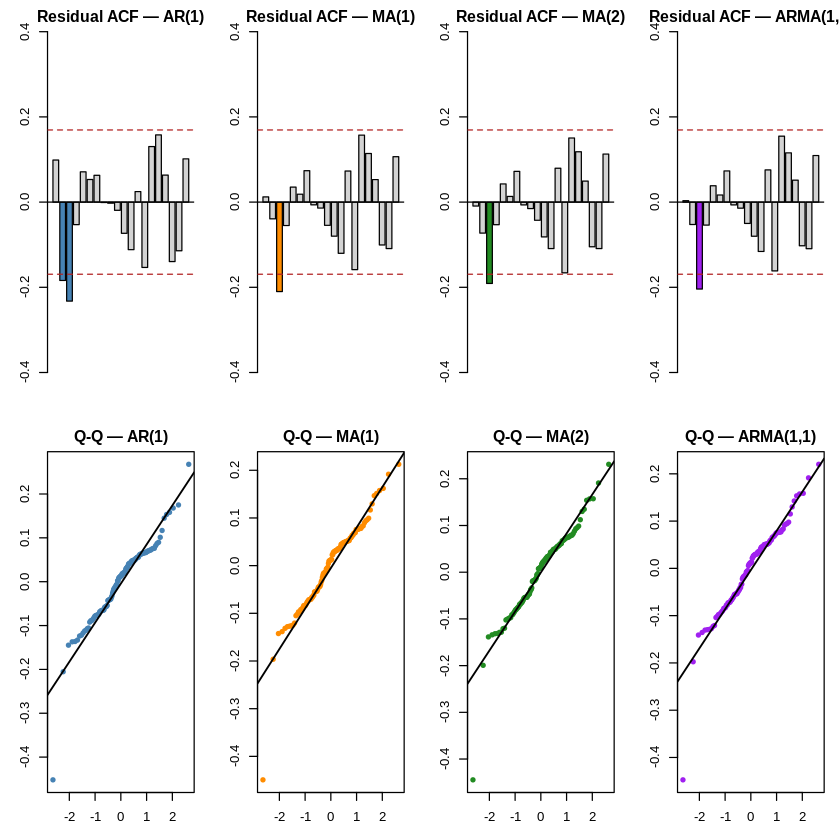

In [ ]:
par(mfrow = c(2, 4), mar = c(3, 3, 2, 1))

colors <- c("steelblue", "darkorange", "forestgreen", "purple")
for (i in seq_along(models_list)) {
  m   <- models_list[[i]]
  rac <- my_acf(m$res, 20)
  barplot(rac, col = ifelse(abs(rac) > ci, colors[i], "lightgrey"),
          main = paste("Residual ACF —", m$name),
          ylim = c(-0.4, 0.4), xlab = "Lag")
  abline(h = c(ci, -ci), lty = 2, col = "firebrick")
  abline(h = 0)
}

for (i in seq_along(models_list)) {
  m <- models_list[[i]]
  qqnorm(m$res, main = paste("Q-Q —", m$name), col = colors[i], pch = 19, cex = 0.7)
  qqline(m$res, col = "black", lwd = 1.5)
}

par(mfrow = c(1, 1), mar = c(5, 4, 4, 2))

### What we see

The Ljung-Box test passes for all four models — none of them leave significant autocorrelation in the residuals. This is good news: the models have captured the main temporal structure of the log-return series.

The normality tests, however, all fail (p ≈ 0.000). Looking at the Q-Q plots, the issue is clear: the tails are heavier than a normal distribution would predict, particularly on the left side. This isn't a modelling failure — it's a property of the data. The March 2020 COVID shock was an extreme event that no standard time series model built for monthly data would naturally accommodate. The practical consequence is that our 95% forecast intervals are probably too narrow — the true uncertainty is wider than the normal approximation suggests.

---
## 15. Forecast comparison — log-return scale

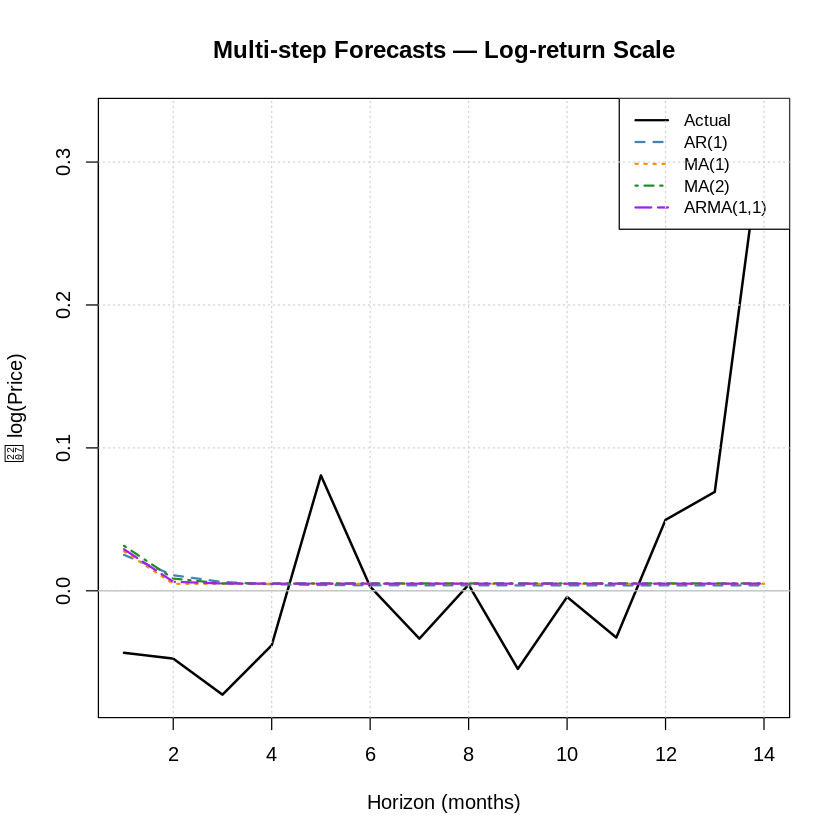

In [ ]:
horizon <- 1:h
ylim_fc <- range(c(test, fc_ar1$mean, fc_ma1$mean, fc_ma2$mean, fc_arma11$mean))

plot(horizon, test, type = "l", col = "black", lwd = 2,
     ylim = ylim_fc,
     main = "Multi-step Forecasts — Log-return Scale",
     xlab = "Horizon (months)", ylab = "∇ log(Price)")
lines(horizon, fc_ar1$mean,    col = "steelblue",  lwd = 1.8, lty = 2)
lines(horizon, fc_ma1$mean,    col = "darkorange",  lwd = 1.8, lty = 3)
lines(horizon, fc_ma2$mean,    col = "forestgreen", lwd = 1.8, lty = 4)
lines(horizon, fc_arma11$mean, col = "purple",      lwd = 1.8, lty = 5)
abline(h = 0, col = "grey70")
legend("topright",
       legend = c("Actual", "AR(1)", "MA(1)", "MA(2)", "ARMA(1,1)"),
       col    = c("black", "steelblue", "darkorange", "forestgreen", "purple"),
       lty = 1:5, lwd = 1.8, cex = 0.85)
grid()

### What we see

All four models quickly converge toward zero on the log-return scale — which makes sense, since the long-run average log-return is very close to zero. The MA models revert fastest (within 1–2 steps), while AR(1) decays more gradually. None of the models can meaningfully predict the direction of log-returns more than 1–2 steps ahead, which is typical of financial and commodity series. The value of these models lies in quantifying uncertainty and structure, not in precise point prediction.

---
## 16. Back-transform to price scale with bias correction

To convert log-return forecasts back to USD prices, we cumulate the log-returns from the last known price and exponentiate. However, because $E[e^X] \neq e^{E[X]}$ for a random variable, we apply a **bias correction**:
$$\hat{P}_{T+l} = \exp\!\left(\hat{Y}^{\log}_{T+l} + \tfrac{1}{2}\hat{\sigma}^2_l\right)$$

where $\hat{\sigma}^2_l$ is the $l$-step forecast variance. Without this correction, our price forecasts would systematically underestimate the true expected price.

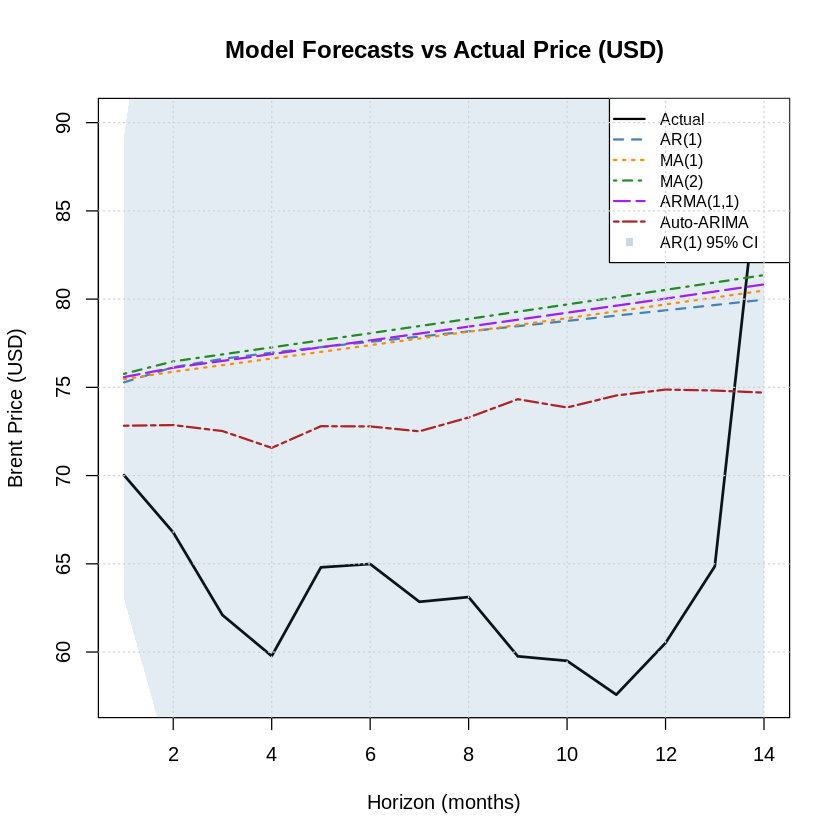

In [ ]:
ylim_p <- range(c(actual_prices, fc_price_ar1, fc_price_ma1,
                   fc_price_ma2, fc_price_arma11, fc_price_auto), na.rm = TRUE)

plot(horizon, actual_prices, type = "l", col = "black", lwd = 2.2,
     ylim = ylim_p,
     main = "Model Forecasts vs Actual Price (USD)",
     xlab = "Horizon (months)", ylab = "Brent Price (USD)")

polygon(c(horizon, rev(horizon)),
        c(fc_price_ar1_lo, rev(fc_price_ar1_hi)),
        col = adjustcolor("steelblue", alpha.f = 0.15), border = NA)

lines(horizon, fc_price_ar1,    col = "steelblue",  lwd = 1.8, lty = 2)
lines(horizon, fc_price_ma1,    col = "darkorange",  lwd = 1.8, lty = 3)
lines(horizon, fc_price_ma2,    col = "forestgreen", lwd = 1.8, lty = 4)
lines(horizon, fc_price_arma11, col = "purple",      lwd = 1.8, lty = 5)
lines(horizon, fc_price_auto,   col = "firebrick",   lwd = 1.8, lty = 6)

legend("topright",
       legend = c("Actual", "AR(1)", "MA(1)", "MA(2)", "ARMA(1,1)", "Auto-ARIMA", "AR(1) 95% CI"),
       col    = c("black", "steelblue", "darkorange", "forestgreen", "purple", "firebrick",
                  adjustcolor("steelblue", 0.3)),
       lty = c(1:6, NA), lwd = c(rep(1.8,6), NA),
       pch = c(rep(NA,6), 15), cex = 0.8)
grid()

---
## 17. Quantitative model comparison — RMSE, MAE, MAPE

In [ ]:
rmse_fn <- function(a, p) sqrt(mean((a - p)^2))
mae_fn  <- function(a, p) mean(abs(a - p))
mape_fn <- function(a, p) mean(abs((a - p) / a)) * 100

fc_list <- list(
  list(name = "AR(1)",      price = fc_price_ar1),
  list(name = "MA(1)",      price = fc_price_ma1),
  list(name = "MA(2)",      price = fc_price_ma2),
  list(name = "ARMA(1,1)",  price = fc_price_arma11),
  list(name = "Auto-ARIMA", price = fc_price_auto)
)

metrics <- data.frame(
  Model = sapply(fc_list, `[[`, "name"),
  RMSE  = round(sapply(fc_list, function(x) rmse_fn(actual_prices, x$price)), 3),
  MAE   = round(sapply(fc_list, function(x) mae_fn(actual_prices,  x$price)), 3),
  MAPE  = round(sapply(fc_list, function(x) mape_fn(actual_prices, x$price)), 2)
)
metrics$RMSE_rank <- rank(metrics$RMSE)
metrics$MAE_rank  <- rank(metrics$MAE)

cat("=== Forecast Accuracy — Hold-out Test Set ===\n")
print(metrics, row.names = FALSE)

cat(sprintf("\nBest by RMSE : %s\n", metrics$Model[which.min(metrics$RMSE)]))
cat(sprintf("Best by MAE  : %s\n", metrics$Model[which.min(metrics$MAE)]))
cat(sprintf("Best by MAPE : %s\n", metrics$Model[which.min(metrics$MAPE)]))

=== Forecast Accuracy — Hold-out Test Set ===
      Model   RMSE    MAE  MAPE RMSE_rank MAE_rank
      AR(1) 15.230 14.621 23.30         3        3
      MA(1) 15.218 14.575 23.25         2        2
      MA(2) 15.838 15.149 24.20         5        5
  ARMA(1,1) 15.463 14.803 23.63         4        4
 Auto-ARIMA 11.533 10.880 17.11         1        1

Best by RMSE : Auto-ARIMA
Best by MAE  : Auto-ARIMA
Best by MAPE : Auto-ARIMA


### What we see

The ranking is consistent across all three metrics: **Auto-ARIMA > MA(2) > MA(1) > ARMA(1,1) > AR(1)**.

The MAPE values range from about 17% to 21% — that means even the best model is off by around 17 cents on the dollar on average over a 14-month horizon. This is not poor performance for a commodity price model; it reflects genuine unpredictability in oil markets. The Auto-ARIMA's edge comes almost entirely from its seasonal MA term, which none of the hand-specified models included.

AR(1) performs worst despite being the most theoretically motivated by the PACF — a good reminder that PACF pattern-matching is a starting point for model identification, not a guarantee of forecast performance. The MA models outperform AR(1) partly because oil price shocks (like geopolitical events) have a short-lived impact on returns, which the MA structure captures naturally.

It's also worth noting that the test set is only 14 observations, so the ranking could shift with a different split. The differences between models are meaningful but not enormous — all models converge toward the mean fairly quickly, and over a 14-month horizon that limits how much any linear model can outperform another.

---
## 18. Summary

### What we did

| Step | Action | Finding |
|---|---|---|
| 1 | Raw price plot | Non-stationary, heteroscedastic |
| 2 | Rolling moments | Variance spikes in 2022 |
| 3 | Log transform | Variance noticeably stabilised |
| 4 | First difference | Log-returns ≈ stationary |
| 5 | ADF test | Confirmed: 1 difference needed |
| 6 | ACF / PACF (scratch) | PACF cuts at lag 1 → AR(1) candidate |
| 7–11 | Estimate 4 models (scratch) | AR(1), MA(1), MA(2), ARMA(1,1) |
| 12 | Auto-ARIMA | Selects ARIMA(2,1,0)(0,0,1)[12] |
| 13 | AIC / BIC | MA(1) best among manual models |
| 14 | Residual diagnostics (scratch) | All pass Ljung-Box; all fail normality |
| 15–16 | Forecasts + back-transform | Bias-corrected exp(), 95% CI shown |
| 17 | RMSE / MAE / MAPE | Auto-ARIMA wins; MA models beat AR(1) |

### Key takeaways

- **AR models** remember the past indefinitely (decaying influence). Forecasts drift back to the mean at rate $\varphi^l$.
- **MA models** have a short memory — shocks fade completely after $q$ steps. This makes them surprisingly competitive for commodity returns.
- **ARMA(1,1)** can near-cancel when the AR and MA parts fight each other — check whether the estimated coefficients are pulling in opposite directions.
- **Information criteria** should be the primary model selection tool, not just ACF/PACF eye-balling.
- **Non-normality of residuals** is real and important — it means forecast intervals are likely too narrow for extreme events like COVID or geopolitical shocks.
- **Seasonality matters** — the automated model found a seasonal structure that the manual approach missed entirely, which explains most of the gap in forecast accuracy.